In [1]:
import copy
import itertools
import joblib
import warnings

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.exceptions import ConvergenceWarning

import shap

/Users/mel/venu_master/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Importation des données

In [2]:
choix = pd.read_csv("../Data/Traffic_Violations-API_20260324.csv", sep=";")
vetements = pd.read_excel("../Data/fashion_data_2018_2022.xls")

In [3]:
nb_ligne_av = len(choix)

In [4]:
choix = choix.drop(columns=['Time Of Stop', 'Agency', 'SubAgency', 'Description', 'Location', 'Accident', 'Belts', 'Personal Injury', 'Property Damage', 'Fatal', 'Commercial License', 'HAZMAT', 'Alcohol', 'Work Zone', 'Violation Type', 'Charge', 'Article', 'Contributed To Accident', 'Arrest Type', 'Geolocation', 'Latitude', 'Longitude', 'Driver City', 'State', 'DL State', 'Year' ])

avant = len(choix)
temp = choix[choix["VehicleType"] == "02 - Automobile"]
temp = temp.dropna()
apres = len(temp)
perte = avant - apres
pourcentage = (perte / avant) * 100
print(f"Perte de {perte} lignes, soit {pourcentage:.2f} %")

choix = temp

# Convertir en datetime
choix['Date Of Stop'] = pd.to_datetime(choix['Date Of Stop'], format='%m/%d/%Y', errors='coerce')
choix['Year'] = choix['Date Of Stop'].dt.year

basic_colors = ['silver', 'chrome', 'gray', 'white', 'black']
choix['Color'] = choix['Color'].str.lower()
choix['Color Type'] = choix['Color'].apply(lambda x: 'basic' if x in basic_colors else 'not basic')

vetements = vetements[['product_id', 'gender', 'category', 'pattern', 'color', 'age_group', 'sales_count', 'month_of_sale', 'year_of_sale']]

Perte de 243644 lignes, soit 11.58 %


On ne garde que les informations relatives a la voiture et au conducteur.

In [5]:
Meetdeal_mark = ['Citroen', 'Hyundai', 'Seat', 'Skoda', 'Volkswagen', 'CUPRA', 'OPEL', 'Dacia', 'Renault', 'DS', 'VWU',       'AUDI', 'Fiat', 'Peugeot', 'KIA', 'AlfaRomeo', 'Honda', 'Lancia', 'Toyota']

Meetdeal_mark = [x.upper() for x in Meetdeal_mark]

In [6]:
import re
import pandas as pd

# Liste en majuscules + homogénéisée
Meetdeal_mark = [
    'CITROEN','HYUNDAI','SEAT','SKODA','VOLKSWAGEN',
    'CUPRA','OPEL','DACIA','RENAULT','DS',
    'VWU','AUDI','FIAT','PEUGEOT','KIA',
    'ALFAROMEO','HONDA','LANCIA','TOYOTA'
]

def normalize_make(x):
    if pd.isna(x):
        return x
    
    x = x.upper().strip()
    x = re.sub(r'[^A-Z0-9 ]', '', x)

    # Mapping uniquement vers tes marques
    patterns = {
        r'.*\bTOY.*': 'TOYOTA',
        r'.*\bHON.*': 'HONDA',
        r'.*\bHYUN.*|.*\bHYN.*': 'HYUNDAI',
        r'.*\bKIA.*': 'KIA',
        r'.*\bVOLK.*|.*\bVW.*': 'VOLKSWAGEN',
        r'.*\bAUD.*': 'AUDI',
        r'.*\bFIAT.*': 'FIAT',
        r'.*\bPEUG.*': 'PEUGEOT',
        r'.*\bCITR.*': 'CITROEN',
        r'.*\bREN.*': 'RENAULT',
        r'.*\bDAC.*': 'DACIA',
        r'.*\bOPEL.*': 'OPEL',
        r'.*\bSEAT.*': 'SEAT',
        r'.*\bSKO.*': 'SKODA',
        r'.*\bCUPRA.*': 'CUPRA',
        r'.*\bDS.*': 'DS',
        r'.*\bALFA.*': 'ALFAROMEO',
        r'.*\bLANC.*': 'LANCIA'
    }

    for pattern, brand in patterns.items():
        if re.match(pattern, x):
            return brand
    
    return None  # 👈 important : on rejette tout le reste

before = len(choix)
choix["Make"] = choix["Make"].apply(normalize_make)
choix = choix[choix["Make"].isin(Meetdeal_mark)]
after = len(choix)

perte = before - after
pourcentage = perte / before

print(f"Perte de {perte} lignes, soit {pourcentage:.2f} %")

Perte de 1042050 lignes, soit 0.56 %


In [7]:
print(list(choix["Make"].unique()))

['HONDA', 'TOYOTA', 'VOLKSWAGEN', 'HYUNDAI', 'AUDI', 'KIA', 'ALFAROMEO', 'FIAT', 'PEUGEOT']


In [8]:
Meetdeal_modele = ['C3 aircross', 'C3', 'Ami', 'Tucson', 'Arona', 'Kamiq', 'Taigo', 'Leon', 'C4', 'C5 aircross', 'Vivaro', 'Mokka','Corsa', 'C5 x', 'Kona', 'C4 x', 'Polo', 'Astra', 'Grandland', 'Captur', 'Up!', 'E-up!', 'Crossland', 'Combo', 'Ds 4', 'Ds 7', 'Movano', 'T-roc', 'Id.3', 'Bigster', 'Ibiza', 'I10', 'Bayon', 'Tiguan', 'Octavia', 'Transporter', 'Fabia', 'Karoq', 'Golf', 'T-cross', 'A3', 'Elroq', '600', '208', 'Frontera', 'Niro', 'Stonic', 'Ceed', 'Inster', 'Sportage', 'Picanto', 'Tonale', 'Jazz', 'Q4 e-tron', 'Ateca', 'Id.4', 'Formentor', 'Tayron', 'Born', 'Ev3', '600e', 'Junior', 'Topolino', 'Ds 3', '500e', 'Hr-v', 'Ev6', '408', 'Ypsilon', 'Kodiaq', 'Q5', 'Q2', 'A1', 'I20', 'Terramar', 'Tavascan', 'Q3', 'Enyaq', 'Yaris', 'A6']

Meetdeal_modele = [x.upper() for x in Meetdeal_modele]

In [9]:
def normalize_model(x):
    if pd.isna(x):
        return x

    x = str(x).upper().strip()
    x = re.sub(r'[^A-Z0-9 ]', '', x)

    # Mapping des motifs vers les modèles standardisés
    patterns = {
        # Modèles Citroën
        r'.*\bC3.*AIRCROSS.*': 'C3 AIRCROSS',
        r'.*\bC3\b.*': 'C3',
        r'.*\bC4.*AIRCROSS.*': 'C4 AIRCROSS',
        r'.*\bC4.*X.*': 'C4 X',
        r'.*\bC4\b.*': 'C4',
        r'.*\bC5.*AIRCROSS.*': 'C5 AIRCROSS',
        r'.*\bC5.*X.*': 'C5 X',
        # Modèles Hyundai
        r'.*\bTUCSON.*': 'TUCSON',
        r'.*\bKONA.*': 'KONA',
        r'.*\bI10.*': 'I10',
        r'.*\bI20.*': 'I20',
        # Modèles Seat
        r'.*\bARONA.*': 'ARONA',
        r'.*\bLEON.*': 'LEON',
        r'.*\bIBIZA.*': 'IBIZA',
        # Modèles Skoda
        r'.*\bKAMIQ.*': 'KAMIQ',
        r'.*\bOCTAVIA.*': 'OCTAVIA',
        r'.*\bKAROQ.*': 'KAROQ',
        # Modèles Volkswagen
        r'.*\bPOLO.*': 'POLO',
        r'.*\bGOLF.*': 'GOLF',
        r'.*\bT\-?ROC.*': 'T-ROC',
        r'.*\bID\.?3.*': 'ID.3',
        r'.*\bID\.?4.*': 'ID.4',
        r'.*\bUP.*': 'UP!',
        r'.*\bE\-?UP.*': 'E-UP!',
        # Modèles Opel
        r'.*\bCORSA.*': 'CORSA',
        r'.*\bASTRA.*': 'ASTRA',
        r'.*\bGRANDLAND.*': 'GRANDLAND',
        r'.*\bCROSSLAND.*': 'CROSSLAND',
        r'.*\bCOMBO.*': 'COMBO',
        r'.*\bVIVARO.*': 'VIVARO',
        r'.*\bMOVANO.*': 'MOVANO',
        # Modèles Dacia
        r'.*\bDS\b.*3.*': 'DS 3',
        r'.*\bDS\b.*4.*': 'DS 4',
        r'.*\bDS\b.*7.*': 'DS 7',
        # Modèles Renault
        r'.*\bCAPTUR.*': 'CAPTUR',
        # Modèles Toyota
        r'.*\bYARIS.*': 'YARIS',
        r'.*\bCOROLLA.*': 'COROLLA',  # À adapter selon ta liste
        # Modèles Kia
        r'.*\bNIRO.*': 'NIRO',
        r'.*\bSTONIC.*': 'STONIC',
        r'.*\bCEED.*': 'CEED',
        r'.*\bSPORTAGE.*': 'SPORTAGE',
        r'.*\bPICANTO.*': 'PICANTO',
        # Modèles Honda
        r'.*\bJAZZ.*': 'JAZZ',
        r'.*\bHR\-?V.*': 'HR-V',
        # Modèles Audi
        r'.*\bA3.*': 'A3',
        r'.*\bA6.*': 'A6',
        r'.*\bQ2.*': 'Q2',
        r'.*\bQ3.*': 'Q3',
        r'.*\bQ5.*': 'Q5',
        r'.*\bQ4.*E\-?TRON.*': 'Q4 E-TRON',
        # Modèles Peugeot
        r'.*\b208.*': '208',
        r'.*\b408.*': '408',
        # Modèles Fiat
        r'.*\b500.*E.*': '500E',
        r'.*\bYPSILON.*': 'YPSILON',
        # Modèles Cupra
        r'.*\bATECA.*': 'ATECA',
        r'.*\bFORMENTOR.*': 'FORMENTOR',
        # Modèles Alfa Romeo
        r'.*\bTONALE.*': 'TONALE',
        # Modèles Lancia
        r'.*\bYPSILON.*': 'YPSILON',
        # Modèles DS
        r'.*\bDS\b.*3.*': 'DS 3',
        r'.*\bDS\b.*4.*': 'DS 4',
        r'.*\bDS\b.*7.*': 'DS 7',
        # Modèles divers
        r'.*\bTERRAMAR.*': 'TERRAMAR',
        r'.*\bTAVASCAN.*': 'TAVASCAN',
        r'.*\bENYAQ.*': 'ENYAQ',
        r'.*\bEV6.*': 'EV6',
        r'.*\bEV3.*': 'EV3',
        r'.*\b600E.*': '600E',
        r'.*\bJUNIOR.*': 'JUNIOR',
        r'.*\bTOPOLINO.*': 'TOPOLINO',
    }

    for pattern, model in patterns.items():
        if re.match(pattern, x):
            return model

    return None

# Application
before = len(choix)
choix["Model"] = choix["Model"].apply(normalize_model)
choix = choix[choix["Model"].isin(Meetdeal_modele)]
after = len(choix)

perte = before - after
pourcentage = perte / before

print(f"Perte de {perte} lignes, soit {pourcentage:.2%} du dataset initial.")

Perte de 802223 lignes, soit 98.07% du dataset initial.


In [10]:
print(list(choix["Model"].unique()))

['HR-V', 'Q5', 'YARIS', 'A3', 'ID.4', 'SPORTAGE', 'TUCSON', 'GOLF', 'NIRO', 'KONA', 'Q3', 'A6', 'EV6', 'POLO', 'Q4 E-TRON', 'Q2', 'UP!']


In [11]:
nb_ligne_ap = len(choix)

perte = nb_ligne_av - nb_ligne_ap
pourcentage = (perte / nb_ligne_av) * 100
print(f"Au final : \n Perte de {perte} lignes, soit {pourcentage:.2f} % \n Nombre de ligne finale : {nb_ligne_ap}")

Au final : 
 Perte de 2087917 lignes, soit 99.25 % 
 Nombre de ligne finale : 15773


In [12]:
choix.head()

,Date Of Stop,Commercial Vehicle,VehicleType,Make,Model,Color,Race,Gender,Driver State,Year,Color Type
45,2026-03-23,No,02 - Automobile,HONDA,HR-V,gray,BLACK,M,MD,2026,basic
88,2026-03-22,No,02 - Automobile,AUDI,Q5,"blue, light",BLACK,F,MD,2026,not basic
89,2026-03-22,No,02 - Automobile,AUDI,Q5,"blue, light",BLACK,F,MD,2026,not basic
543,2026-03-21,No,02 - Automobile,TOYOTA,YARIS,silver,HISPANIC,F,MD,2026,basic
551,2026-03-21,No,02 - Automobile,AUDI,A3,black,BLACK,F,MD,2026,basic


In [13]:
vetements.head()

,product_id,gender,category,pattern,color,age_group,sales_count,month_of_sale,year_of_sale
0,1001,Male,Shirt,Geometric,White,25-35,75,1,2018
1,1002,Male,Jacket,Polka Dots,Beige,18-24,296,1,2018
2,1003,Female,Dress,Geometric,Brown,18-24,50,1,2018
3,1004,Male,Shorts,Plain,White,25-35,435,1,2018
4,1005,Male,Shirt,Plain,Beige,35-45,79,1,2018


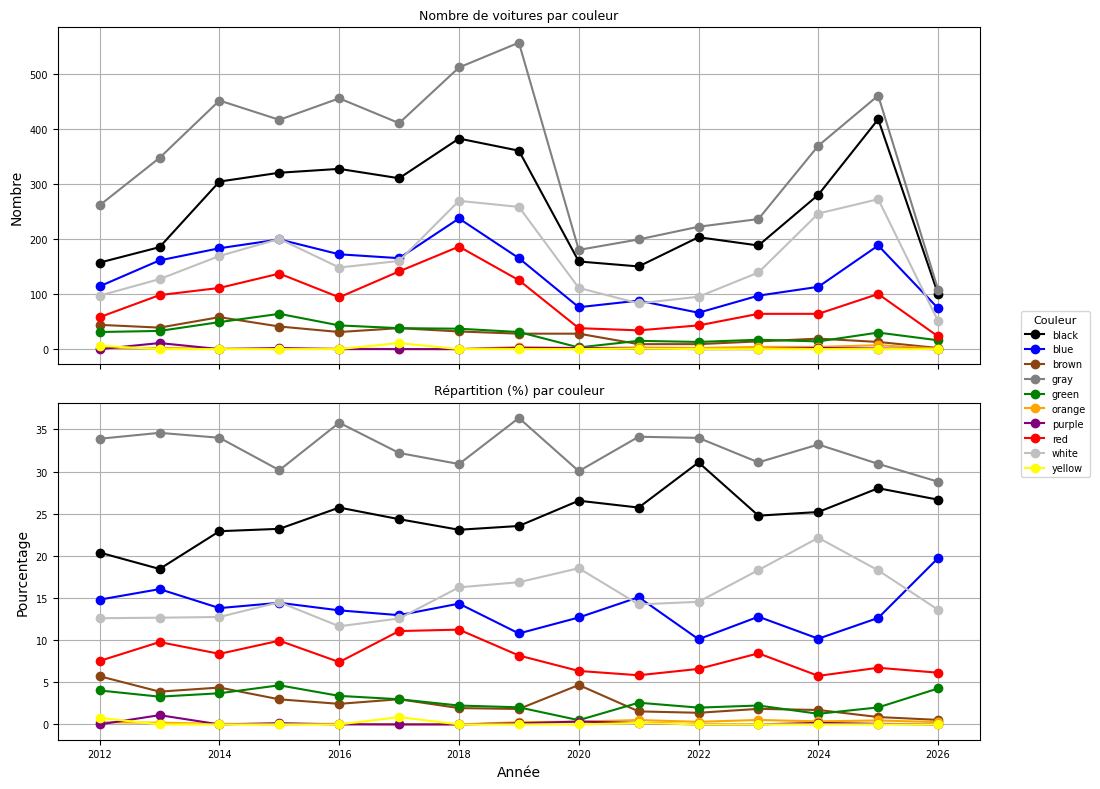

In [64]:
# -----------------------------
# Préparation des données
# -----------------------------

color_map = {
    'blue': ['blue', 'blue, light', 'blue, dark'],
    'green': ['green', 'green, lgt', 'green, dk'],
    'red': ['red', 'maroon'],
    'brown': ['brown', 'tan', 'cream', 'gold', 'bronze', 'copper', 'beige'],
    'white': ['white'],
    'black': ['black'],
    'orange': ['orange'],
    'yellow': ['yellow'],
    'pink': ['pink'],
    'purple': ['purple'],
    'multicolor': ['multicolor', 'camouflage'],
    'gray': ['silver', 'chrome', 'gray']
}

def general_color(c):
    for gen, shades in color_map.items():
        if c in shades:
            return gen
    return 'other'

choix['Color_general'] = choix['Color'].apply(general_color)

counts = choix.groupby(['Year', 'Color_general']).size().unstack(fill_value=0)
counts_percent = counts.div(counts.sum(axis=1), axis=0) * 100

palette = {
    'blue': 'blue',
    'green': 'green',
    'red': 'red',
    'brown': 'saddlebrown',
    'white': 'silver',
    'black': 'black',
    'orange': 'orange',
    'yellow': 'yellow',
    'pink': 'pink',
    'purple': 'purple',
    'multicolor': 'magenta',
    'gray': 'gray',
    'other': 'cyan'
}

# -----------------------------
# Subplots
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

lines = []
labels = []

# ---- Graphique 1 ----
for color in counts.columns:
    line, = axes[0].plot(
        counts.index,
        counts[color],
        marker='o',
        color=palette.get(color, 'gray'),
        label=color
    )
    lines.append(line)
    labels.append(color)

axes[0].set_title("Nombre de voitures par couleur")
axes[0].set_ylabel("Nombre")
axes[0].grid(True)

# ---- Graphique 2 ----
for color in counts_percent.columns:
    axes[1].plot(
        counts_percent.index,
        counts_percent[color],
        marker='o',
        color=palette.get(color, 'gray')
    )

axes[1].set_title("Répartition (%) par couleur")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Pourcentage")
axes[1].grid(True)

# -----------------------------
# Légende unique
# -----------------------------
fig.legend(
    lines, labels,
    title="Couleur",
    loc='center right',
    bbox_to_anchor=(1.1, 0.5),
    fontsize=7,
    title_fontsize=8
)

# Ajustements taille texte
for ax in axes:
    ax.tick_params(labelsize=7)
    ax.title.set_size(9)

plt.tight_layout()
plt.show()

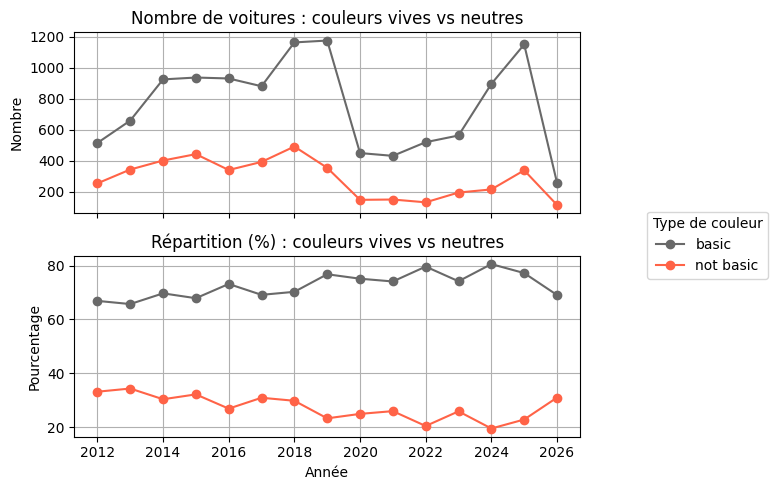

In [15]:
# -----------------------------
# 2️⃣ Agrégation
# -----------------------------
counts = choix.groupby(['Year', 'Color Type']).size().unstack(fill_value=0)
counts_percent = counts.div(counts.sum(axis=1), axis=0) * 100

# -----------------------------
# 3️⃣ Palette
# -----------------------------
palette = {
    'not basic': 'tomato',
    'basic': 'dimgray',
    'other': 'cyan'
}

# -----------------------------
# 4️⃣ Subplots
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

lines = []
labels = []

# ---- Graphique 1 ----
for t in counts.columns:
    line, = axes[0].plot(
        counts.index,
        counts[t],
        marker='o',
        color=palette.get(t, 'black'),
        label=t
    )
    lines.append(line)
    labels.append(t)

axes[0].set_title("Nombre de voitures : couleurs vives vs neutres")
axes[0].set_ylabel("Nombre")
axes[0].grid(True)

# ---- Graphique 2 ----
for t in counts_percent.columns:
    axes[1].plot(
        counts_percent.index,
        counts_percent[t],
        marker='o',
        color=palette.get(t, 'black')
    )

axes[1].set_title("Répartition (%) : couleurs vives vs neutres")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Pourcentage")
axes[1].grid(True)

# -----------------------------
# 5️⃣ Légende unique
# -----------------------------
fig.legend(lines, labels, title="Type de couleur",
           loc='center right', bbox_to_anchor=(1.3, 0.5))

plt.tight_layout()
plt.show()

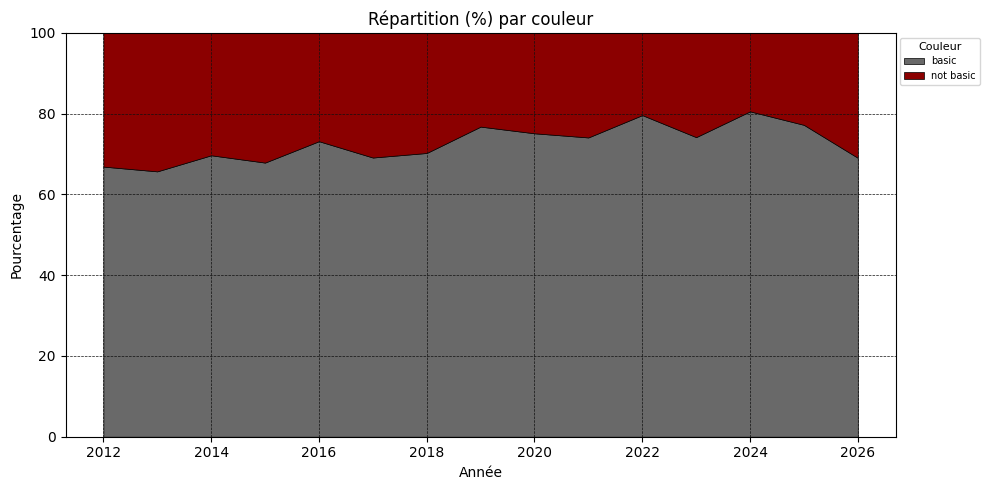

In [61]:
import matplotlib.pyplot as plt

# -----------------------------
# Graphique unique : aire empilée pour Color_general
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 5))

# Créer la liste des couleurs en remplaçant "not basic" par darkred
colors_ordered = counts_percent.columns.tolist()
colors_plot = [
    'darkred' if color == 'not basic' else palette.get(color, 'gray')
    for color in colors_ordered
]

# Stackplot
stack = ax.stackplot(
    counts_percent.index,
    [counts_percent[color] for color in colors_ordered],
    colors=colors_plot,
    labels=colors_ordered
)

# Ajouter contours foncés pour chaque zone
for poly in stack:
    poly.set_edgecolor('black')
    poly.set_linewidth(0.5)

ax.set_title("Répartition (%) par couleur")
ax.set_xlabel("Année")
ax.set_ylabel("Pourcentage")
ax.set_ylim(0, 100)

# Grille très foncée
ax.grid(True, color='#111111', linestyle='--', linewidth=0.5)

# Légende
ax.legend(title="Couleur", fontsize=7, title_fontsize=8, loc='upper left', bbox_to_anchor=(1,1))

plt.tight_layout()
plt.show()

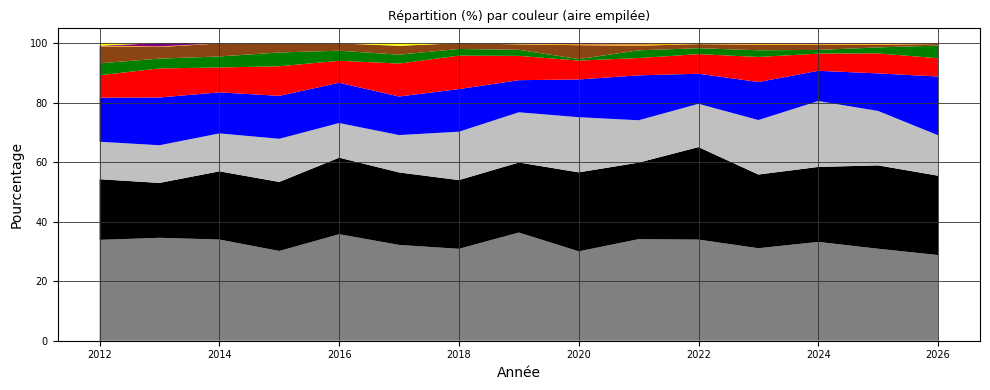

In [69]:
# -----------------------------
# Tri des couleurs (du + grand au + petit)
# -----------------------------
order = counts_percent.sum().sort_values(ascending=False).index

counts_percent_sorted = counts_percent[order]

# -----------------------------
# Graphique aire empilée trié
# -----------------------------
fig2, ax2 = plt.subplots(figsize=(10, 4))

colors = [palette.get(c, 'gray') for c in counts_percent_sorted.columns]

ax2.stackplot(
    counts_percent_sorted.index,
    counts_percent_sorted.T,
    labels=counts_percent_sorted.columns,
    colors=colors
)

ax2.set_title("Répartition (%) par couleur (aire empilée)")
ax2.set_xlabel("Année")
ax2.set_ylabel("Pourcentage")
ax2.grid(True, color='#333333', linestyle='-', linewidth=0.6)

ax2.legend(title="Couleur", fontsize=7, title_fontsize=8, loc='upper left')

ax2.tick_params(labelsize=7)
ax2.title.set_size(9)
ax2.legend().remove()

plt.tight_layout()
plt.show()

La baisse des accidents de la route aux États-Unis en 2020 est principalement due à la pandémie de COVID-19, qui a fortement réduit les déplacements (confinements, télétravail). Moins de voitures sur les routes = moins d’accidents.

# Prédiction 

In [16]:
variables = ["Make", "Model", "VehicleType", "Driver State", "Gender", "Race"]

for var in variables:
    table = pd.crosstab(choix[var], choix["Color_general"])
    _, p, _, _ = chi2_contingency(table)
    print(f"{var} → p-value = {p:.2f}")

Make → p-value = 0.00
Model → p-value = 0.00
VehicleType → p-value = 1.00
Driver State → p-value = 0.00
Gender → p-value = 0.00
Race → p-value = 0.00


## Info interne

### Couleur précise

#### Random Forest

Le modèle peut produire des prédictions pour des années futures (ex : 2030), mais celles-ci reposent sur l’hypothèse que les tendances observées dans les données historiques restent stables dans le temps.

In [17]:
# Features (X) et target (y)
X = choix[["Commercial Vehicle", "Year", "Make", "Model", "Race", "Gender", "Driver State"]]
y = choix["Color_general"]

In [18]:
categorical_cols = X.columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [19]:
model_precis = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier())
])

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
model_precis.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
y_pred = model_precis.predict(X_test)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred, average="weighted"))

Accuracy : 0.42345483359746433
F1-score : 0.4099897882327514


In [23]:
# Récupérer le modèle entraîné
rf = model_precis.named_steps["classifier"]

# Récupérer les noms des variables après OneHotEncoder
feature_names = model_precis.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(X.columns)

# Importance des variables
importances = rf.feature_importances_

# DataFrame lisible
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_imp.head(20))

            feature  importance
44       Race_WHITE    0.050516
65  Driver State_MD    0.048113
40       Race_BLACK    0.043945
41    Race_HISPANIC    0.041386
45         Gender_F    0.038502
46         Gender_M    0.037967
43       Race_OTHER    0.036466
7         Year_2018    0.035605
14        Year_2025    0.034347
8         Year_2019    0.032358
53  Driver State_DC    0.031760
39       Race_ASIAN    0.031676
6         Year_2017    0.031137
13        Year_2024    0.030595
12        Year_2023    0.029231
5         Year_2016    0.027799
86  Driver State_VA    0.027624
4         Year_2015    0.027093
11        Year_2022    0.026527
3         Year_2014    0.025994


#### Autres

In [24]:

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [25]:
# -----------------------------
# 1. FEATURES / TARGET
# -----------------------------
features = ["Year", "Make", "Model", "Driver State"]
target = "Color_general"

# Tri temporel
choix = choix.sort_values("Year")

# Split temporel
train = choix[choix["Year"] < 2025]
test = choix[choix["Year"] >= 2025]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# -----------------------------
# 🔥 ENCODAGE TARGET (IMPORTANT)
# -----------------------------
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# -----------------------------
# 2. PREPROCESSING
# -----------------------------
categorical_cols = ["Make", "Model", "Driver State"]
numeric_cols = ["Year"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# -----------------------------
# 3. MODELS
# -----------------------------

models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    
    "GradientBoosting": GradientBoostingClassifier(),
    
    "LogisticRegression": LogisticRegression(max_iter=1000),
    
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        use_label_encoder=False,
        eval_metric="mlogloss"
    )
}

# -----------------------------
# 4. TRAIN + EVALUATE
# -----------------------------
print("=== Modèles avec OneHotEncoder ===")

for name, clf in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", clf)
    ])
    
    # ⚠️ utiliser y encodé
    pipe.fit(X_train, y_train_enc)
    y_pred = pipe.predict(X_test)
    
    acc = accuracy_score(y_test_enc, y_pred)
    f1 = f1_score(y_test_enc, y_pred, average="weighted")
    
    print(f"{name} : Accuracy={acc:.4f} | F1={f1:.4f}")

# -----------------------------
# 5. CATBOOST (sans OneHot)
# -----------------------------
print("\n=== CatBoost (catégories natives) ===")

cat_features = ["Make", "Model", "Driver State"]

cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)

# CatBoost accepte y texte directement
cat_model.fit(X_train, y_train, cat_features=cat_features)

y_pred_cat = cat_model.predict(X_test)

# ⚠️ flatten car CatBoost retourne parfois un array 2D
y_pred_cat = y_pred_cat.flatten()

acc_cat = accuracy_score(y_test, y_pred_cat)
f1_cat = f1_score(y_test, y_pred_cat, average="weighted")

print(f"CatBoost : Accuracy={acc_cat:.4f} | F1={f1_cat:.4f}")

=== Modèles avec OneHotEncoder ===
RandomForest : Accuracy=0.3113 | F1=0.2536
GradientBoosting : Accuracy=0.3194 | F1=0.2480
LogisticRegression : Accuracy=0.3290 | F1=0.2270
XGBoost : Accuracy=0.3119 | F1=0.2310

=== CatBoost (catégories natives) ===
CatBoost : Accuracy=0.3113 | F1=0.2336


### Type de couleur

#### Random Forest

In [26]:
# Features (X) et target (y)
X = choix[["Commercial Vehicle", "Year", "Make", "Model", "Race", "Gender", "Driver State"
]]
y = choix["Color Type"]

In [27]:
categorical_cols = X.columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [28]:
model_general = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
model_general.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
y_pred = model_general.predict(X_test)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred, average="weighted"))

Accuracy : 0.7613312202852615
F1-score : 0.7354003130320441


#### Autres

In [32]:
# -----------------------------
# 1. FEATURES / TARGET
# -----------------------------
features = ["Year", "Make", "Model", "Driver State", "Gender"]
target = "Color Type"

# Tri temporel
choix = choix.sort_values("Year")

# Split temporel
train = choix[choix["Year"] < 2025]
test = choix[choix["Year"] >= 2025]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# -----------------------------
# 🔥 ENCODAGE TARGET
# -----------------------------
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# -----------------------------
# 2. PREPROCESSING
# -----------------------------
categorical_cols = ["Make", "Model", "Driver State", "Gender"]
numeric_cols = ["Year"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# -----------------------------
# 3. MODELS
# -----------------------------
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        use_label_encoder=False,
        eval_metric="mlogloss"
    )
}

# -----------------------------
# 4. TRAIN + EVALUATE
# -----------------------------
results = []

for name, clf in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", clf)
    ])
    
    # entraînement
    pipe.fit(X_train, y_train_enc)
    y_pred = pipe.predict(X_test)
    
    acc = accuracy_score(y_test_enc, y_pred)
    f1 = f1_score(y_test_enc, y_pred, average="weighted")
    
    print(f"{name} : Accuracy={acc:.4f} | F1={f1:.4f}")
    
    # stocker résultats
    results.append({
        "name": name,
        "model": pipe,
        "accuracy": acc,
        "f1": f1
    })

# -----------------------------
# 5. CATBOOST (sans OneHot)
# -----------------------------
cat_features = ["Make", "Model", "Driver State", "Gender"]

cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)

cat_model.fit(X_train, y_train, cat_features=cat_features)
y_pred_cat = cat_model.predict(X_test).flatten()

acc_cat = accuracy_score(y_test, y_pred_cat)
f1_cat = f1_score(y_test, y_pred_cat, average="weighted")

print(f"CatBoost : Accuracy={acc_cat:.4f} | F1={f1_cat:.4f}")

# Ajouter CatBoost aux résultats
results.append({
    "name": "CatBoost",
    "model": cat_model,
    "accuracy": acc_cat,
    "f1": f1_cat
})

# -----------------------------
# 6. SÉLECTION DU MEILLEUR MODÈLE
# -----------------------------
# Trier par accuracy (desc) puis F1 (desc)
results_sorted = sorted(results, key=lambda x: (x["accuracy"], x["f1"]), reverse=True)

best_model_info = results_sorted[0]
best_model_name = best_model_info["name"]
best_model = best_model_info["model"]
best_accuracy = best_model_info["accuracy"]
best_f1 = best_model_info["f1"]

print(f"\n=== Meilleur modèle ===")
print(f"{best_model_name} | Accuracy={best_accuracy:.4f} | F1={best_f1:.4f}")

# Maintenant `best_model` peut être utilisé pour prédiction, SHAP, etc.

RandomForest : Accuracy=0.7407 | F1=0.6478
GradientBoosting : Accuracy=0.7558 | F1=0.6506
LogisticRegression : Accuracy=0.7552 | F1=0.6524
XGBoost : Accuracy=0.7472 | F1=0.6474
CatBoost : Accuracy=0.7547 | F1=0.6501

=== Meilleur modèle ===
GradientBoosting | Accuracy=0.7558 | F1=0.6506


In [33]:
# -----------------------------
# 1. Transformer X_test
# -----------------------------
X_test_transformed = best_model.named_steps["preprocessor"].transform(X_test)

# Si sparse, convertir en dense
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Convertir en DataFrame avec noms des features
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# Forcer toutes les colonnes en float
X_test_df = X_test_df.apply(pd.to_numeric, errors='coerce')

# -----------------------------
# 2. Créer l’explainer SHAP selon le type de modèle
# -----------------------------
if best_model_name == "LogisticRegression":
    explainer = shap.LinearExplainer(
        best_model.named_steps["model"],
        X_test_df,
        feature_perturbation="interventional"
    )
    shap_values = explainer.shap_values(X_test_df)

elif best_model_name in ["RandomForest", "GradientBoosting", "XGBoost"]:
    explainer = shap.TreeExplainer(best_model.named_steps["model"])
    shap_values = explainer.shap_values(X_test_df)

elif best_model_name == "CatBoost":
    # CatBoost accepte le DataFrame original avec cat_features
    pool = best_model.Pool(X_test, cat_features=cat_features)
    shap_values = best_model.get_feature_importance(data=pool, type="ShapValues")
    shap_values = shap_values[:, :-1]  # retirer base_value

# -----------------------------
# 3. Calculer l’importance globale
# -----------------------------
if isinstance(shap_values, list):  # multiclass
    shap_importance = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    shap_importance = np.abs(shap_values).mean(axis=0)

# DataFrame interprétable
shap_df = pd.DataFrame({
    "feature": X_test_df.columns if best_model_name != "CatBoost" else features,
    "importance": shap_importance
}).sort_values("importance", ascending=False)

# -----------------------------
# 4. Afficher top 20 features
# -----------------------------
print(shap_df.head(20))

                 feature  importance
67             num__Year    0.372007
0         cat__Make_AUDI    0.261783
1        cat__Make_HONDA    0.149873
10       cat__Model_HR-V    0.096232
4       cat__Make_TOYOTA    0.040519
12       cat__Model_KONA    0.029859
20      cat__Model_YARIS    0.022677
3          cat__Make_KIA    0.016881
11       cat__Model_ID.4    0.013197
16         cat__Model_Q5    0.011651
6          cat__Model_A3    0.011148
64         cat__Gender_F    0.010307
13       cat__Model_NIRO    0.008474
26  cat__Driver State_DC    0.007916
66         cat__Gender_U    0.007231
65         cat__Gender_M    0.006747
15         cat__Model_Q3    0.006505
5   cat__Make_VOLKSWAGEN    0.005609
18     cat__Model_TUCSON    0.004762
29  cat__Driver State_GA    0.003888


#### Meilleur info a mettre

In [34]:
# -----------------------------
# 1. PREPARATION
# -----------------------------
target = "Color Type"

choix = choix.sort_values("Year")

train = choix[choix["Year"] < 2025]
test = choix[choix["Year"] >= 2025]

le = LabelEncoder()
y_train = le.fit_transform(train[target])
y_test = le.transform(test[target])

other_features = ["Make", "Model", "Driver State", "Race", "Gender"]

# -----------------------------
# 2. MODELS
# -----------------------------
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric="mlogloss"
    )
}

# -----------------------------
# 3. STOCKAGE RESULTATS
# -----------------------------
results = []

best_model = None
best_score = 0
best_f1 = 0
best_features = None
best_model_name = None

# -----------------------------
# 4. TEST DES COMBINAISONS
# -----------------------------
for r in range(len(other_features) + 1):
    for subset in itertools.combinations(other_features, r):

        features = ["Year"] + list(subset)

        X_train = train[features]
        X_test = test[features]

        categorical_cols = [col for col in features if col != "Year"]

        transformers = []

        if categorical_cols:
            transformers.append(
                ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
            )

        transformers.append(("num", "passthrough", ["Year"]))

        preprocessor = ColumnTransformer(transformers)

        for name, clf in models.items():

            pipe = Pipeline([
                ("preprocessor", preprocessor),
                ("model", clf)
            ])

            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average="weighted")

            results.append({
                "features": str(features),
                "model": name,
                "accuracy": acc,
                "f1": f1
            })

            # 🔥 BEST MODEL
            if (acc > best_score) or (acc == best_score and f1 > best_f1):
                best_score = acc
                best_f1 = f1
                best_model = copy.deepcopy(pipe)
                best_features = features
                best_model_name = name

In [35]:
# -----------------------------
# DATAFRAME RESULTATS
# -----------------------------
df_results = pd.DataFrame(results)

print("\n=== TOP 5 DES RESULTATS ===")
print(df_results.sort_values(by=["accuracy", "f1"], ascending=False).head(5))

print("\n🏆 MEILLEUR MODELE")
print("Modèle :", best_model_name)
print("Features :", best_features)
print("Accuracy :", best_score)
print("F1 :", best_f1)


=== TOP 5 DES RESULTATS ===
                              features               model  accuracy        f1
87  ['Year', 'Make', 'Race', 'Gender']             XGBoost  0.757381  0.667422
84  ['Year', 'Make', 'Race', 'Gender']        RandomForest  0.756307  0.667682
10                   ['Year', 'Model']  LogisticRegression  0.755770  0.651646
26           ['Year', 'Make', 'Model']  LogisticRegression  0.755770  0.651646
46           ['Year', 'Model', 'Race']  LogisticRegression  0.755770  0.651646

🏆 MEILLEUR MODELE
Modèle : XGBoost
Features : ['Year', 'Make', 'Race', 'Gender']
Accuracy : 0.7573805689747719
F1 : 0.6674216770596564


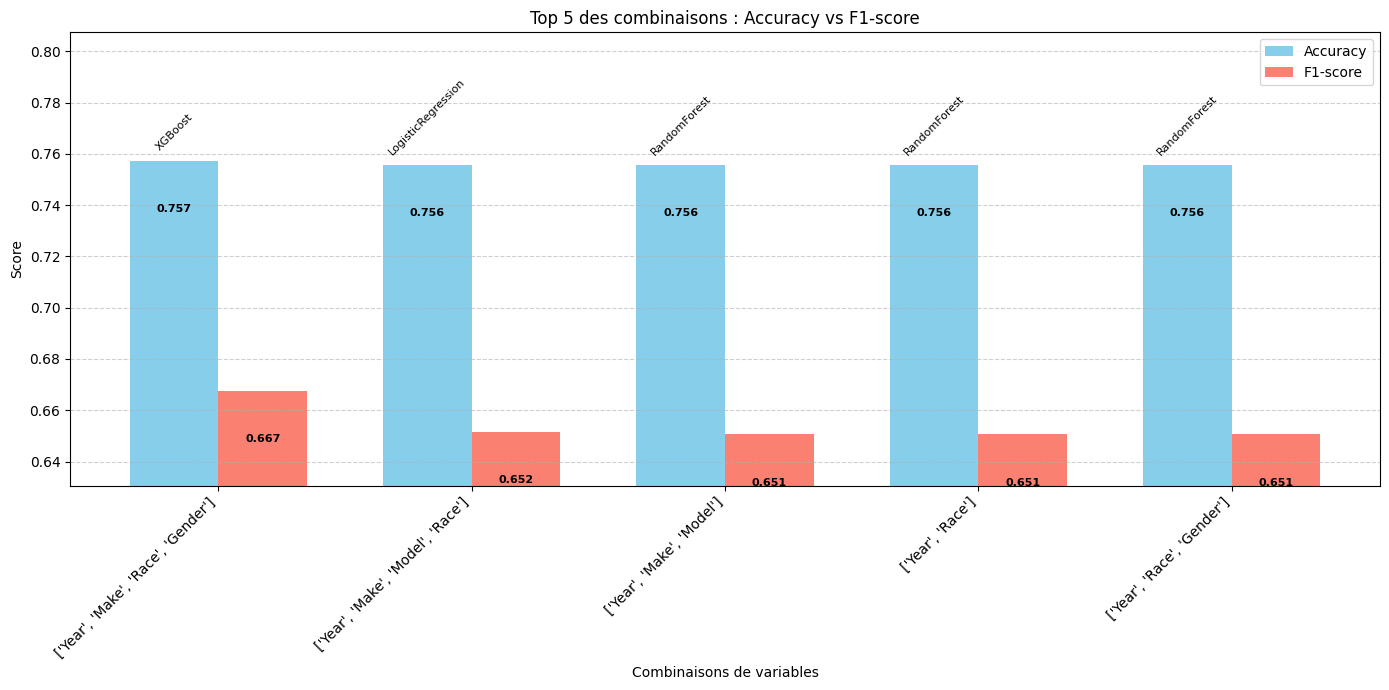

In [36]:
# -----------------------------
# MEILLEUR MODELE PAR COMBINAISON
# -----------------------------
best_per_combination = df_results.loc[
    df_results.groupby("features")["accuracy"].idxmax()
].copy()

# -----------------------------
# TOP 5
# -----------------------------
top5 = best_per_combination.sort_values("accuracy", ascending=False).head(5)

top5["label"] = top5["features"].astype(str)

# -----------------------------
# POSITION DES BARRES
# -----------------------------
x = np.arange(len(top5))
width = 0.35

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(14,7))

bars1 = plt.bar(x - width/2, top5["accuracy"], width, label="Accuracy", color="skyblue")
bars2 = plt.bar(x + width/2, top5["f1"], width, label="F1-score", color="salmon")

# -----------------------------
# LABELS SUR LES BARRES
# -----------------------------
for bar, model in zip(bars1, top5["model"]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        model,
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=45
    )

# Valeurs sur les barres
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height - 0.02, f"{height:.3f}",
             ha='center', fontsize=8, fontweight="bold")

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height - 0.02, f"{height:.3f}",
             ha='center', fontsize=8, fontweight="bold")

# -----------------------------
# AXES
# -----------------------------
plt.xticks(x, top5["label"], rotation=45, ha="right")

min_val = min(top5["accuracy"].min(), top5["f1"].min())
max_val = max(top5["accuracy"].max(), top5["f1"].max())

plt.ylim(min_val - 0.02, max_val + 0.05)

# -----------------------------
# STYLE
# -----------------------------
plt.xlabel("Combinaisons de variables")
plt.ylabel("Score")
plt.title("Top 5 des combinaisons : Accuracy vs F1-score")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

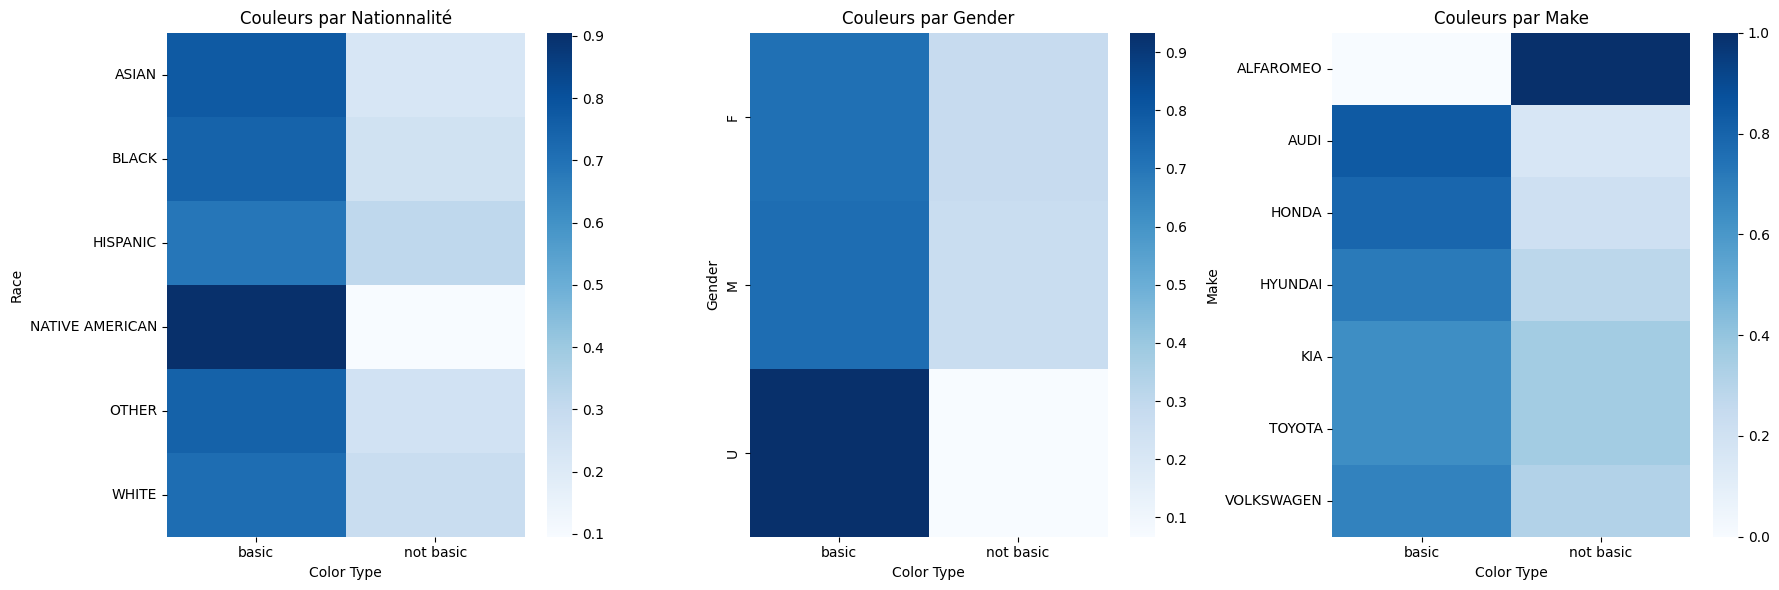

In [54]:
# -----------------------------
# TABLES
# -----------------------------
table_race = pd.crosstab(choix["Race"], choix["Color Type"], normalize="index")
table_gender = pd.crosstab(choix["Gender"], choix["Color Type"], normalize="index")
table_make = pd.crosstab(choix["Make"], choix["Color Type"], normalize="index")

# -----------------------------
# PLOT
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18,6))

# 🔹 Race
sns.heatmap(table_race, cmap="Blues", ax=axes[0])
axes[0].set_title("Couleurs par Nationnalité")

# 🔹 Gender
sns.heatmap(table_gender, cmap="Blues", ax=axes[1])
axes[1].set_title("Couleurs par Gender")

# 🔹 Make
sns.heatmap(table_make, cmap="Blues", ax=axes[2])
axes[2].set_title("Couleurs par Make")

# -----------------------------
# STYLE GLOBAL
# -----------------------------
plt.tight_layout()
plt.show()

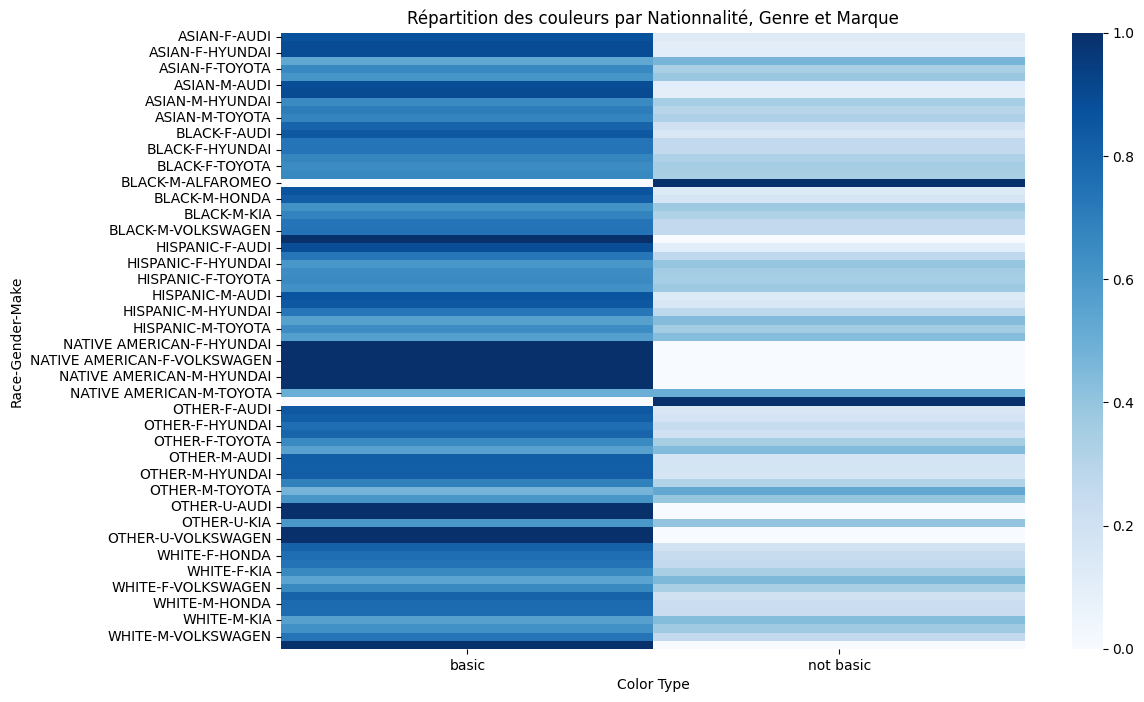

In [53]:
table = pd.crosstab(
    [choix["Race"], choix["Gender"], choix["Make"]],
    choix["Color Type"],
    normalize="index"
)

plt.figure(figsize=(12,8))
sns.heatmap(table, cmap="Blues")
plt.title("Répartition des couleurs par Nationnalité, Genre et Marque")
plt.show()

In [39]:
# -----------------------------
# SAUVEGARDE
# -----------------------------
joblib.dump({
    "model": best_model,
    "features": best_features,
    "label_encoder": le
}, "best_model.pkl")

print("\n💾 Modèle sauvegardé dans best_model.pkl")

# -----------------------------
# REUTILISATION DU MODELE
# -----------------------------
data = joblib.load("best_model.pkl")

best_model = data["model"]
best_features = data["features"]
le = data["label_encoder"]

X_test_best = test[best_features]

predictions = best_model.predict(X_test_best)

# 🔁 retour aux labels d'origine
predictions = le.inverse_transform(predictions)

print("\n🔮 Prédictions prêtes !")


💾 Modèle sauvegardé dans best_model.pkl

🔮 Prédictions prêtes !


Prédictions :
 basic        0.98336
not basic    0.01664
Name: proportion, dtype: float64

Réel :
 basic        0.75577
not basic    0.24423
Name: proportion, dtype: float64


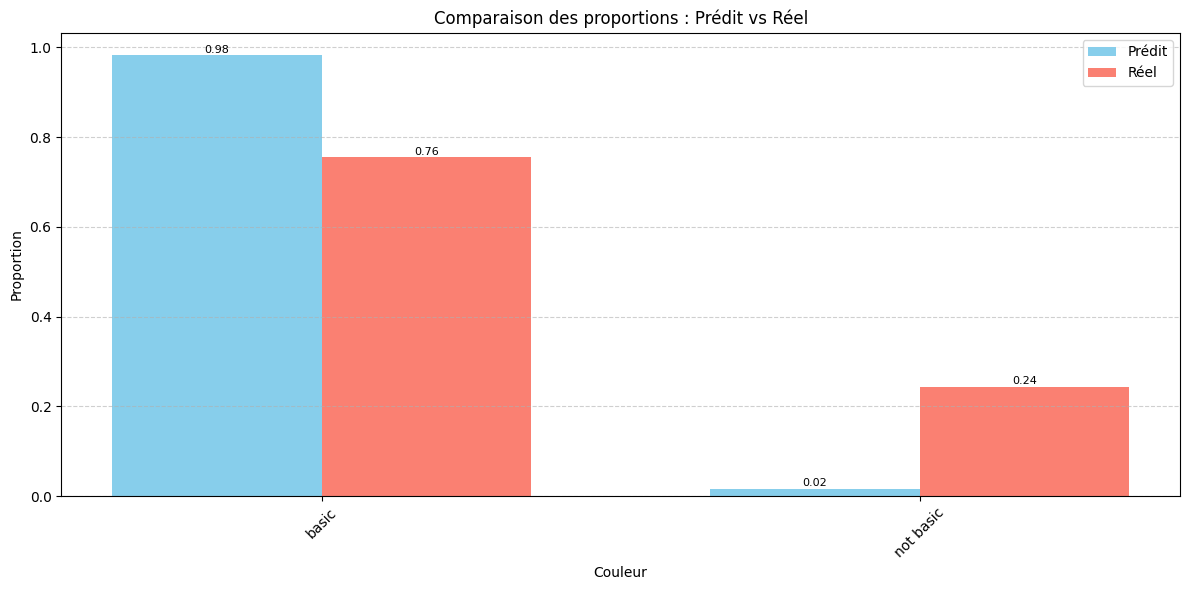

In [40]:
# -----------------------------
# PROPORTIONS PREDICTIONS
# -----------------------------
counts_pred = pd.Series(predictions).value_counts(normalize=True)

# -----------------------------
# PROPORTIONS REELLES
# -----------------------------
y_test_labels = le.inverse_transform(y_test)
counts_real = pd.Series(y_test_labels).value_counts(normalize=True)

print("Prédictions :\n", counts_pred)
print("\nRéel :\n", counts_real)

# -----------------------------
# ALIGNEMENT DES LABELS
# -----------------------------
all_labels = sorted(set(counts_pred.index).union(set(counts_real.index)))

counts_pred = counts_pred.reindex(all_labels, fill_value=0)
counts_real = counts_real.reindex(all_labels, fill_value=0)

# -----------------------------
# POSITIONS
# -----------------------------
x = np.arange(len(all_labels))
width = 0.35

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(12,6))

bars1 = plt.bar(x - width/2, counts_pred, width, label="Prédit", color="skyblue")
bars2 = plt.bar(x + width/2, counts_real, width, label="Réel", color="salmon")

# -----------------------------
# VALEURS SUR LES BARRES
# -----------------------------
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005,
             f"{height:.2f}", ha='center', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005,
             f"{height:.2f}", ha='center', fontsize=8)

# -----------------------------
# AXES
# -----------------------------
plt.xticks(x, all_labels, rotation=45)
plt.xlabel("Couleur")
plt.ylabel("Proportion")

plt.title("Comparaison des proportions : Prédit vs Réel")

# -----------------------------
# STYLE
# -----------------------------
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Couleur précise selon le type de couleur

### Couleur basique

In [41]:
# -----------------------------
# 1. PREPARATION
# -----------------------------
target = "Color_general"

choix = choix.sort_values("Year")
select = choix[choix["Color Type"] == "basic"]

train = select[select["Year"] < 2025]
test = select[select["Year"] >= 2025]

le = LabelEncoder()
y_train = le.fit_transform(train[target])
y_test = le.transform(test[target])

# 👉 variables FIXES
features = ["Year", "Make", "Race", "Gender"]

X_train = train[features]
X_test = test[features]

categorical_cols = ["Make", "Race", "Gender"]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", "passthrough", ["Year"])
])

# -----------------------------
# 2. MODELS
# -----------------------------
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric="mlogloss"
    )
}

# -----------------------------
# 3. TEST DES MODELES
# -----------------------------
results = []

best_model = None
best_score = 0
best_f1 = 0
best_model_name = None

for name, clf in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", clf)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    results.append({
        "model": name,
        "accuracy": acc,
        "f1": f1
    })

    print(f"{name} → Accuracy: {acc:.4f} | F1: {f1:.4f}")

    # 🔥 BEST MODEL
    if (acc > best_score) or (acc == best_score and f1 > best_f1):
        best_score = acc
        best_f1 = f1
        best_model = copy.deepcopy(pipe)
        best_model_name = name

RandomForest → Accuracy: 0.3565 | F1: 0.3465
GradientBoosting → Accuracy: 0.3864 | F1: 0.3011
LogisticRegression → Accuracy: 0.4332 | F1: 0.3609
XGBoost → Accuracy: 0.3580 | F1: 0.3479


In [42]:
# -----------------------------
# DATAFRAME RESULTATS
# -----------------------------
df_results = pd.DataFrame(results)

print("\n=== TOP DES RESULTATS ===")
print(df_results.sort_values(by=["accuracy", "f1"], ascending=False))

print("\n🏆 MEILLEUR MODELE")
print("Modèle :", best_model_name)
print("Accuracy :", best_score)
print("F1 :", best_f1)


=== TOP DES RESULTATS ===
                model  accuracy        f1
2  LogisticRegression  0.433239  0.360873
1    GradientBoosting  0.386364  0.301054
3             XGBoost  0.357955  0.347851
0        RandomForest  0.356534  0.346539

🏆 MEILLEUR MODELE
Modèle : LogisticRegression
Accuracy : 0.43323863636363635
F1 : 0.3608732762133276


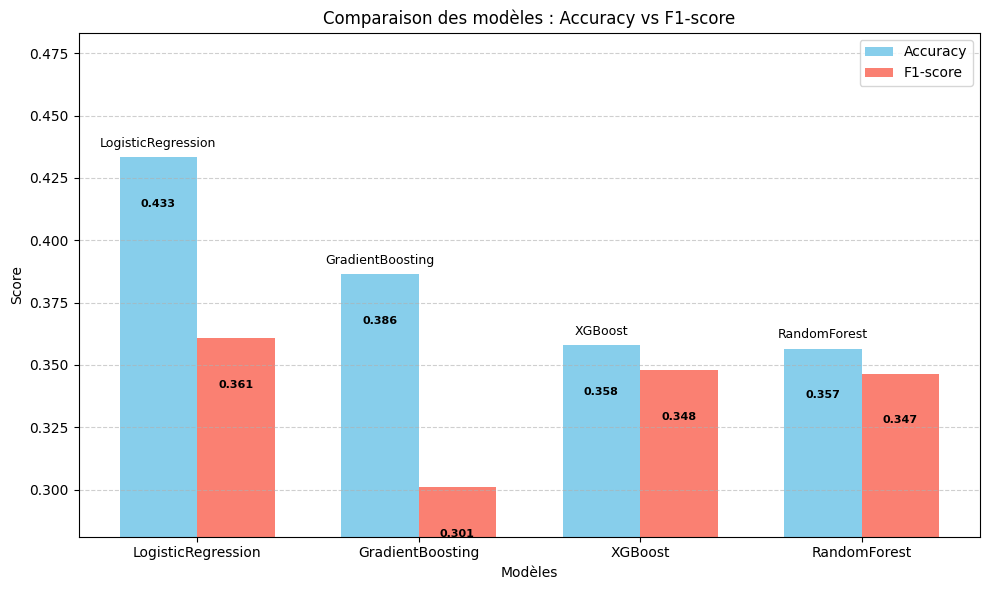

In [43]:
# -----------------------------
# DATAFRAME RESULTATS
# -----------------------------
df_results = pd.DataFrame(results)

# -----------------------------
# TOP MODELS (optionnel)
# -----------------------------
top_models = df_results.sort_values("accuracy", ascending=False).copy()

top_models["label"] = top_models["model"]

# -----------------------------
# POSITION DES BARRES
# -----------------------------
x = np.arange(len(top_models))
width = 0.35

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width/2, top_models["accuracy"], width, label="Accuracy", color="skyblue")
bars2 = plt.bar(x + width/2, top_models["f1"], width, label="F1-score", color="salmon")

# -----------------------------
# LABELS (nom du modèle)
# -----------------------------
for bar, model in zip(bars1, top_models["model"]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        model,
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=0
    )

# -----------------------------
# VALEURS SUR LES BARRES
# -----------------------------
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height - 0.02, f"{height:.3f}",
             ha='center', fontsize=8, fontweight="bold")

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height - 0.02, f"{height:.3f}",
             ha='center', fontsize=8, fontweight="bold")

# -----------------------------
# AXES
# -----------------------------
plt.xticks(x, top_models["label"])

min_val = min(top_models["accuracy"].min(), top_models["f1"].min())
max_val = max(top_models["accuracy"].max(), top_models["f1"].max())

plt.ylim(min_val - 0.02, max_val + 0.05)

# -----------------------------
# STYLE
# -----------------------------
plt.xlabel("Modèles")
plt.ylabel("Score")
plt.title("Comparaison des modèles : Accuracy vs F1-score")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [44]:
# -----------------------------
# SAUVEGARDE
# -----------------------------
joblib.dump({
    "model": best_model,
    "features": features,
    "label_encoder": le
}, "best_model_color_basique.pkl")

print("\n💾 Modèle sauvegardé")


# -----------------------------
# REUTILISATION DU MODELE
# -----------------------------
data = joblib.load("best_model_color_basique.pkl")

best_model_color = data["model"]
best_features = data["features"]
le = data["label_encoder"]

X_test_best = test[best_features]

predictions = best_model_color.predict(X_test_best)

# 🔁 retour aux labels d'origine
predictions = le.inverse_transform(predictions)

print("\n🔮 Prédictions prêtes !")


💾 Modèle sauvegardé

🔮 Prédictions prêtes !


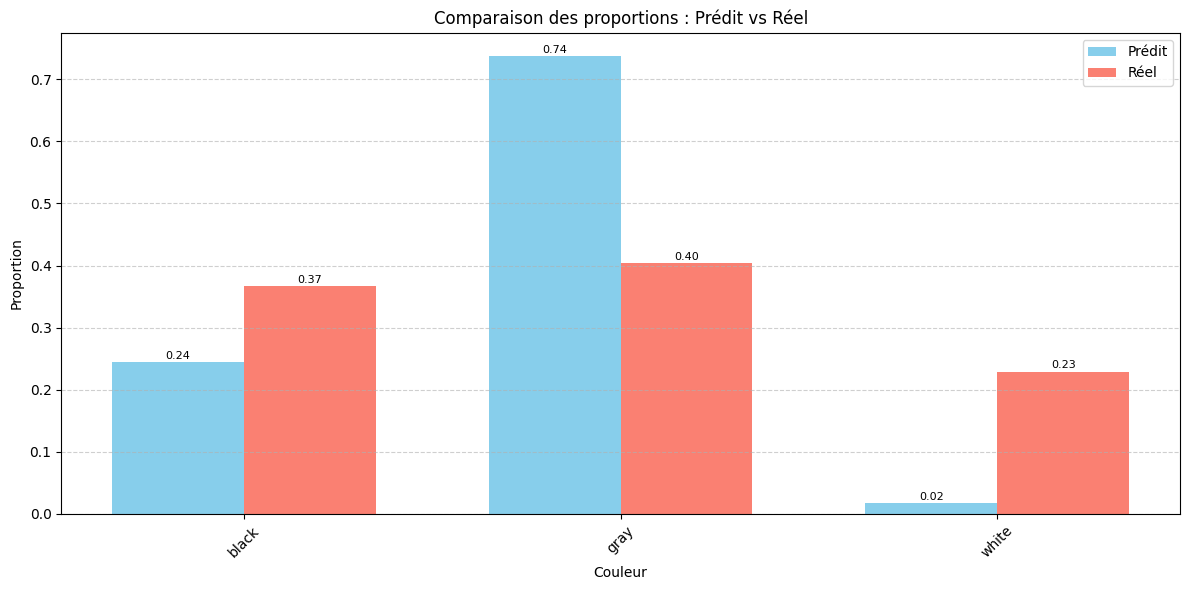

In [45]:
# -----------------------------
# LABELS REELS
# -----------------------------
y_test_labels = le.inverse_transform(y_test)

# -----------------------------
# PROPORTIONS
# -----------------------------
counts_pred = pd.Series(predictions).value_counts(normalize=True)
counts_real = pd.Series(y_test_labels).value_counts(normalize=True)

# -----------------------------
# ALIGNEMENT DES LABELS
# -----------------------------
all_labels = sorted(set(counts_pred.index).union(set(counts_real.index)))

counts_pred = counts_pred.reindex(all_labels, fill_value=0)
counts_real = counts_real.reindex(all_labels, fill_value=0)

# -----------------------------
# POSITIONS
# -----------------------------
x = np.arange(len(all_labels))
width = 0.35

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(12,6))

bars1 = plt.bar(x - width/2, counts_pred, width, label="Prédit", color="skyblue")
bars2 = plt.bar(x + width/2, counts_real, width, label="Réel", color="salmon")

# -----------------------------
# VALEURS SUR LES BARRES
# -----------------------------
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005,
             f"{height:.2f}", ha='center', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005,
             f"{height:.2f}", ha='center', fontsize=8)

# -----------------------------
# AXES
# -----------------------------
plt.xticks(x, all_labels, rotation=45)
plt.ylabel("Proportion")
plt.xlabel("Couleur")

plt.title("Comparaison des proportions : Prédit vs Réel")

# -----------------------------
# STYLE
# -----------------------------
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Couleur non basique

In [46]:
# -----------------------------
# 1. PREPARATION
# -----------------------------
target = "Color_general"

choix = choix.sort_values("Year")
select = choix[choix["Color Type"] != "basic"]

train = select[select["Year"] < 2025]
test = select[select["Year"] >= 2025]

le = LabelEncoder()
y_train = le.fit_transform(train[target])
y_test = le.transform(test[target])

# 👉 variables FIXES
features = ["Year", "Make", "Race", "Gender"]

X_train = train[features]
X_test = test[features]

categorical_cols = ["Make", "Race", "Gender"]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", "passthrough", ["Year"])
])

# -----------------------------
# 2. MODELS
# -----------------------------
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric="mlogloss"
    )
}

# -----------------------------
# 3. TEST DES MODELES
# -----------------------------
results = []

best_model = None
best_score = 0
best_f1 = 0
best_model_name = None

for name, clf in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", clf)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    results.append({
        "model": name,
        "accuracy": acc,
        "f1": f1
    })

    print(f"{name} → Accuracy: {acc:.4f} | F1: {f1:.4f}")

    # 🔥 BEST MODEL
    if (acc > best_score) or (acc == best_score and f1 > best_f1):
        best_score = acc
        best_f1 = f1
        best_model = copy.deepcopy(pipe)
        best_model_name = name

RandomForest → Accuracy: 0.4989 | F1: 0.4766
GradientBoosting → Accuracy: 0.5890 | F1: 0.5225
LogisticRegression → Accuracy: 0.4901 | F1: 0.4573
XGBoost → Accuracy: 0.4637 | F1: 0.4557


In [47]:
# -----------------------------
# DATAFRAME RESULTATS
# -----------------------------
df_results = pd.DataFrame(results)

print("\n=== TOP DES RESULTATS ===")
print(df_results.sort_values(by=["accuracy", "f1"], ascending=False))

print("\n🏆 MEILLEUR MODELE")
print("Modèle :", best_model_name)
print("Accuracy :", best_score)
print("F1 :", best_f1)


=== TOP DES RESULTATS ===
                model  accuracy        f1
1    GradientBoosting  0.589011  0.522509
0        RandomForest  0.498901  0.476586
2  LogisticRegression  0.490110  0.457278
3             XGBoost  0.463736  0.455660

🏆 MEILLEUR MODELE
Modèle : GradientBoosting
Accuracy : 0.589010989010989
F1 : 0.5225089394732252


In [48]:
# -----------------------------
# SAUVEGARDE
# -----------------------------
joblib.dump({
    "model": best_model,
    "features": features,
    "label_encoder": le
}, "best_model_color_non_basique.pkl")

print("\n💾 Modèle sauvegardé")


# -----------------------------
# REUTILISATION DU MODELE
# -----------------------------
data = joblib.load("best_model_color_non_basique.pkl")

best_model_color = data["model"]
best_features = data["features"]
le = data["label_encoder"]

X_test_best = test[best_features]

predictions = best_model_color.predict(X_test_best)

# 🔁 retour aux labels d'origine
predictions = le.inverse_transform(predictions)

print("\n🔮 Prédictions prêtes !")


💾 Modèle sauvegardé

🔮 Prédictions prêtes !


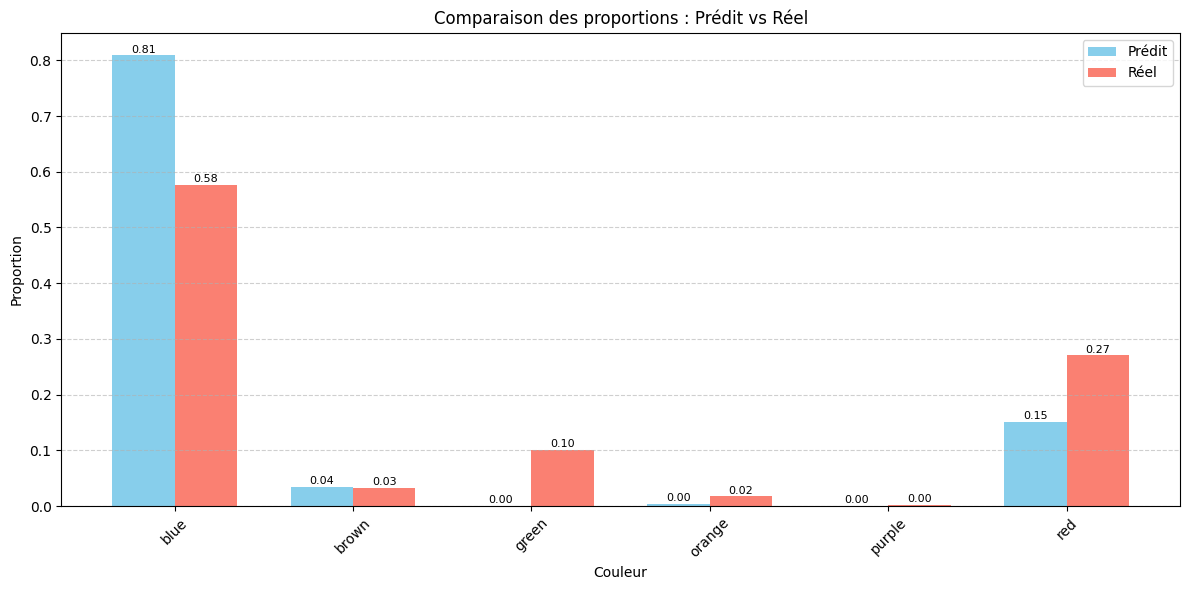

In [49]:
# -----------------------------
# LABELS REELS
# -----------------------------
y_test_labels = le.inverse_transform(y_test)

# -----------------------------
# PROPORTIONS
# -----------------------------
counts_pred = pd.Series(predictions).value_counts(normalize=True)
counts_real = pd.Series(y_test_labels).value_counts(normalize=True)

# -----------------------------
# ALIGNEMENT DES LABELS
# -----------------------------
all_labels = sorted(set(counts_pred.index).union(set(counts_real.index)))

counts_pred = counts_pred.reindex(all_labels, fill_value=0)
counts_real = counts_real.reindex(all_labels, fill_value=0)

# -----------------------------
# POSITIONS
# -----------------------------
x = np.arange(len(all_labels))
width = 0.35

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(12,6))

bars1 = plt.bar(x - width/2, counts_pred, width, label="Prédit", color="skyblue")
bars2 = plt.bar(x + width/2, counts_real, width, label="Réel", color="salmon")

# -----------------------------
# VALEURS SUR LES BARRES
# -----------------------------
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005,
             f"{height:.2f}", ha='center', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005,
             f"{height:.2f}", ha='center', fontsize=8)

# -----------------------------
# AXES
# -----------------------------
plt.xticks(x, all_labels, rotation=45)
plt.ylabel("Proportion")
plt.xlabel("Couleur")

plt.title("Comparaison des proportions : Prédit vs Réel")

# -----------------------------
# STYLE
# -----------------------------
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Vetement 

In [50]:
choix_h = choix[choix['Gender'] == 'M']
vetement_h = vetements[vetements['gender'] == 'Male']

In [51]:
dist_voiture = choix_h['Color'].value_counts(normalize=True)
dist_vetement = vetement_h['color'].value_counts(normalize=True)

Couleurs communes : Index(['black', 'white', 'red', 'green', 'brown', 'beige', 'orange', 'yellow'], dtype='str')


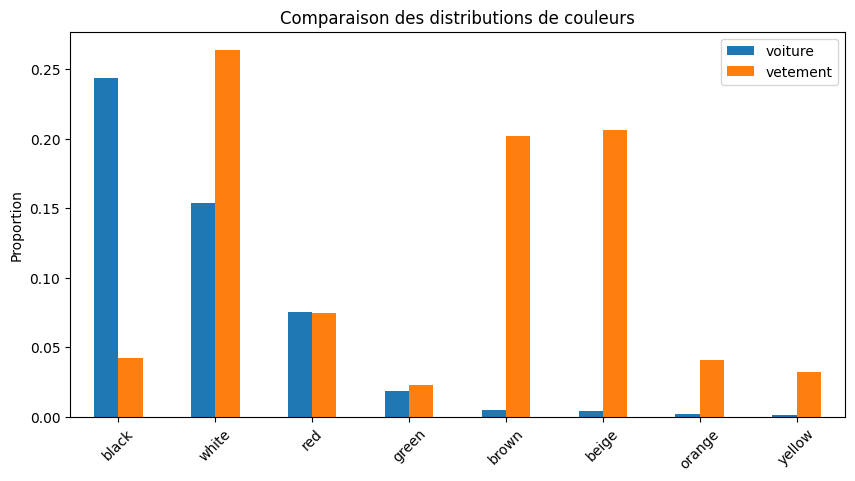

In [52]:
# distributions
dist_voiture = choix['Color'].str.lower().value_counts(normalize=True)
dist_vetement = vetements['color'].str.lower().value_counts(normalize=True)

# couleurs communes
common = dist_voiture.index.intersection(dist_vetement.index)

print("Couleurs communes :", common)

df = pd.DataFrame({
    'voiture': dist_voiture.loc[common],
    'vetement': dist_vetement.loc[common]
})

df.plot(kind='bar', figsize=(10,5))
plt.title("Comparaison des distributions de couleurs")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()